# LightGBM — SBA Loan Default Prediction

LightGBM (Light Gradient Boosting Machine) is a highly efficient gradient boosting framework developed by Microsoft. It uses two key innovations to speed up training without sacrificing accuracy:

- **Gradient-based One-Side Sampling (GOSS)** — retains data points with large gradients (hard examples) and discards a random fraction of small-gradient points
- **Exclusive Feature Bundling (EFB)** — bundles mutually exclusive sparse features to reduce dimensionality

Key advantages for this project:
- Extremely fast training on large datasets
- Built-in `class_weight="balanced"` for handling the ~17% default rate imbalance
- Leaf-wise tree growth (vs. depth-wise) captures complex patterns with fewer splits
- Reliable `feature_importances_` attribute for interpretability

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, precision_recall_curve)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

# ── Load preprocessed data ───────────────────────────────────────────────────
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Default rate — Train: {y_train.mean():.2%}, Test: {y_test.mean():.2%}")

Train: (715993, 12), Test: (178999, 12)
Default rate — Train: 17.57%, Test: 17.57%


## 1. Model Training

LightGBM grows trees leaf-wise (best-leaf-first), unlike most other gradient boosters that grow depth-wise. This enables it to minimise loss more efficiently but can overfit on small datasets without regularisation.

Key hyperparameters:
- `n_estimators=500` — number of boosting rounds
- `learning_rate=0.05` — small learning rate with more trees for better generalisation
- `num_leaves=63` — maximum leaves per tree (controls model complexity; 2^depth - 1 for equivalent depth)
- `class_weight="balanced"` — automatically scales class weights by inverse frequency
- `n_jobs=-1` — parallel training across all CPU cores

In [2]:
%%time
# ── Install LightGBM if not already installed ─────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "lightgbm", "-q"])

# ── Train LightGBM ────────────────────────────────────────────────────────────
import lightgbm as lgb
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=500,        # number of boosting rounds
    learning_rate=0.05,      # small step size — more rounds needed but better fit
    num_leaves=63,           # max leaves per tree (leaf-wise growth)
    class_weight="balanced", # compensate for ~17% default rate imbalance
    random_state=42,
    n_jobs=-1                # use all CPU cores
)

model.fit(X_train, y_train)
print("Model training complete.")


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


[LightGBM] [Info] Number of positive: 125785, number of negative: 590208
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008569 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1261
[LightGBM] [Info] Number of data points in the train set: 715993, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Model training complete.
CPU times: user 18 s, sys: 9.08 s, total: 27 s
Wall time: 7.94 s


## 2. Predictions

Generating hard class labels and default probability scores from the trained LightGBM model.

In [3]:
# ── Generate predictions ──────────────────────────────────────────────────────
y_pred = model.predict(X_test)              # hard class labels (0 or 1)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of default (class 1)

print(f"Predicted defaults: {y_pred.sum()} / {len(y_pred)} ({y_pred.mean():.2%})")
print(f"Actual defaults:    {y_test.sum()} / {len(y_test)} ({y_test.mean():.2%})")

Predicted defaults: 58858 / 178999 (32.88%)
Actual defaults:    31447 / 178999 (17.57%)


## 3. Metric Analysis

### Which metric matters most for this problem?

This is an **imbalanced classification problem** (~17% default rate), which makes metric choice critical:

| Metric | Why it matters here |
|--------|-------------------|
| **Recall** | Most important. Measures how many actual defaults we caught. Missing a default (false negative) means approving a loan that will not be repaid — a direct financial loss. |
| **ROC-AUC** | Measures the model's overall discrimination ability across all thresholds. Robust to class imbalance and useful for comparing models. |
| **PR-AUC** | Even more informative than ROC-AUC on imbalanced data — focuses specifically on the minority (default) class performance. |
| **F1 Score** | Harmonic mean of Precision and Recall. Useful when you need a single number that balances both, but does not capture the full picture. |
| **Accuracy** | **Misleading here.** A naive model that predicts "no default" for every loan would achieve ~83% accuracy — yet it would be completely useless for fraud/default detection. |

**Business context:** In SBA loan default prediction, a **false negative** (predicting "paid in full" when the loan actually defaults) is far more costly than a **false positive** (flagging a good loan as risky). Therefore, we prioritise **Recall** and **ROC-AUC** when evaluating model quality.

> LightGBM's leaf-wise growth and `class_weight="balanced"` make it particularly well-suited for this imbalanced problem, often achieving the best trade-off between Recall and precision among gradient boosting frameworks.

In [4]:
# ── Compute and display all metrics ──────────────────────────────────────────
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Paid in Full", "Defaulted"]))

Accuracy:  0.7487
Precision: 0.3850
Recall:    0.7206
F1 Score:  0.5019
ROC-AUC:   0.8172

Classification Report:
              precision    recall  f1-score   support

Paid in Full       0.93      0.75      0.83    147552
   Defaulted       0.38      0.72      0.50     31447

    accuracy                           0.75    178999
   macro avg       0.66      0.74      0.67    178999
weighted avg       0.83      0.75      0.77    178999



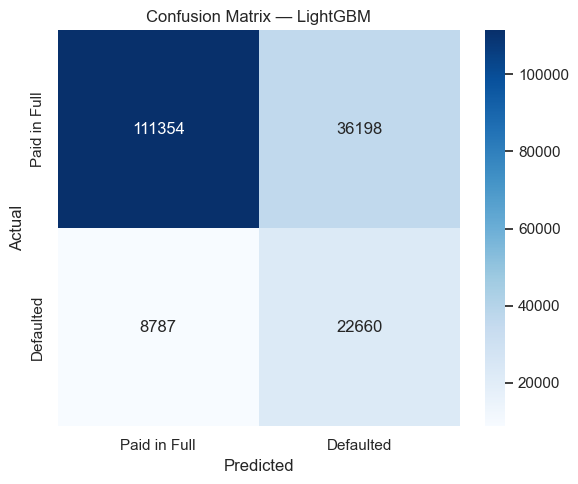

In [5]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Paid in Full", "Defaulted"],
            yticklabels=["Paid in Full", "Defaulted"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — LightGBM")
plt.tight_layout()
plt.show()

# The bottom-left cell (false negatives) represents defaults the model missed.
# Minimising this cell is the primary business objective.

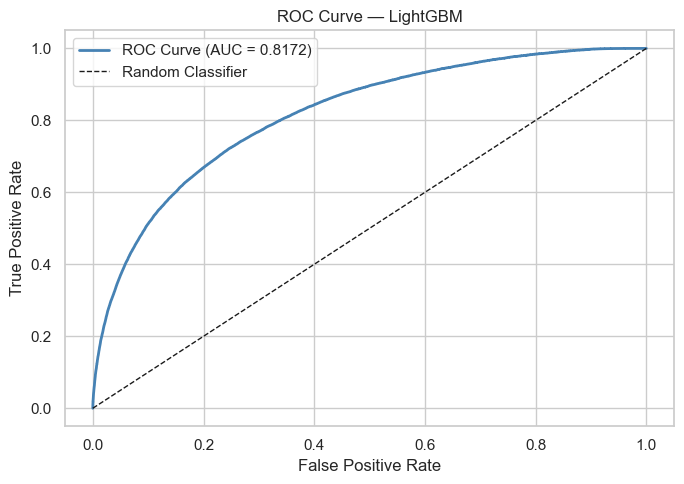

In [6]:
# ── ROC Curve ────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC Curve (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — LightGBM")
ax.legend()
plt.tight_layout()
plt.show()

# A higher AUC means the model better separates defaults from non-defaults
# across all possible decision thresholds.

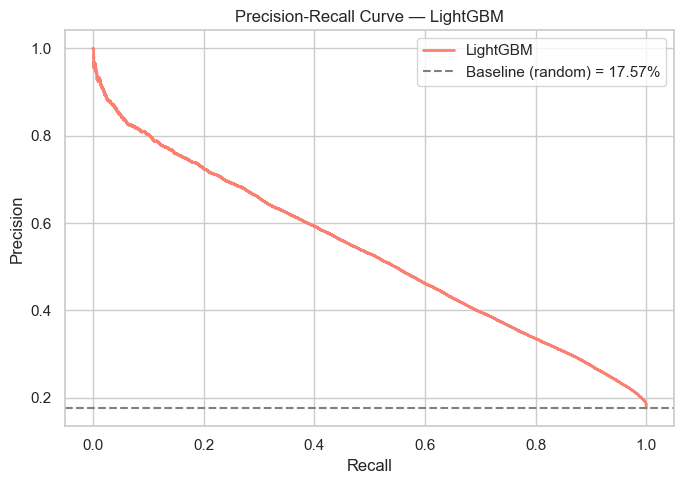

In [7]:
# ── Precision-Recall Curve ───────────────────────────────────────────────────
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_vals, precision_vals, color="salmon", lw=2, label="LightGBM")
ax.axhline(y=y_test.mean(), color="gray", linestyle="--",
           label=f"Baseline (random) = {y_test.mean():.2%}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — LightGBM")
ax.legend()
plt.tight_layout()
plt.show()

# The dashed baseline represents a random classifier at the observed default rate.
# A good model keeps precision well above baseline at high recall values.

## 4. Feature Importance

LightGBM provides feature importances based on how many times each feature was used in a split across all trees (`importance_type="split"`, the default). Alternatively, `importance_type="gain"` weights splits by their total information gain. Here we use the default split-count importance.

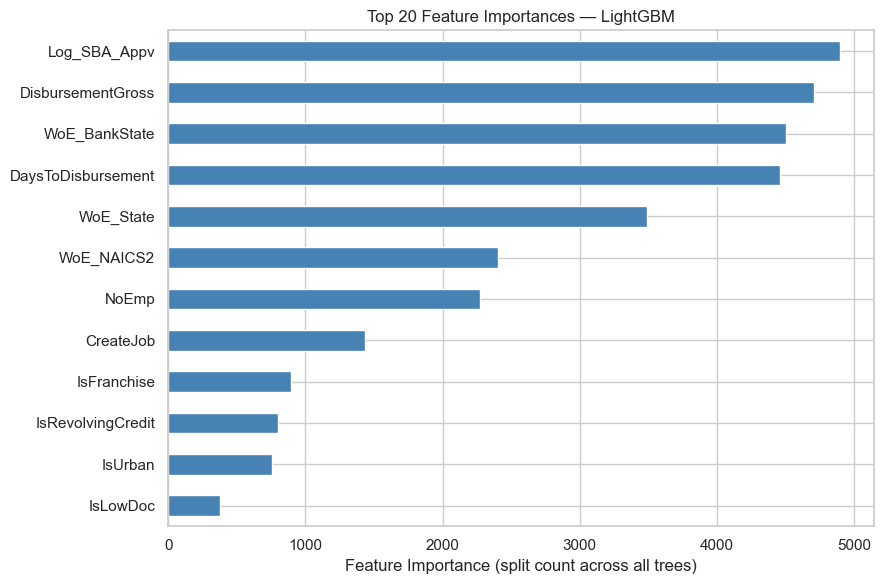

In [8]:
# ── Feature Importance bar chart ─────────────────────────────────────────────
# feature_importances_ uses split-count by default (number of times feature was used in a split)
importances = pd.Series(model.feature_importances_, index=X_train.columns)
top_20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top_20.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Feature Importance (split count across all trees)")
ax.set_title("Top 20 Feature Importances — LightGBM")
plt.tight_layout()
plt.show()

# Features with higher split counts are used more often by the model to
# distinguish defaults from non-defaults across the 500 boosting rounds.